In [1]:
# Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_PATH = "../../datasets/processed/aqi_hourly_clean.csv"
OUT_PATH = "../../datasets/processed/features.csv"

df = pd.read_csv(IN_PATH)
df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])
df = df.sort_values(['location_name', 'datetimeLocal']).reset_index(drop=True)
pollutants = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
df.shape

(7940, 23)

In [2]:
# Adjusting the time features

df['hour'] = df['datetimeLocal'].dt.hour
df['dayofweek'] = df['datetimeLocal'].dt.dayofweek
df['month'] = df['datetimeLocal'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['doy_sin']  = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['doy_cos']  = np.cos(2 * np.pi * df['dayofweek'] / 7)
df[['hour', 'dayofweek', 'hour_sin', 'hour_cos']].head()

,hour,dayofweek,hour_sin,hour_cos
0,16,5,-0.866025,-5.000000e-01
1,17,5,-0.965926,-2.588190e-01
2,18,5,-1.000000,-1.836970e-16
3,19,5,-0.965926,2.588190e-01
4,20,5,-0.866025,5.000000e-01


In [3]:
# Add lags & rolling features per station

def add_lags(g):
    g = g.sort_values('datetimeLocal').copy()
    for col in pollutants + ['AQI']:
        g[f'{col}_lag1']       = g[col].shift(1)
        g[f'{col}_lag3']       = g[col].shift(3)
        g[f'{col}_lag24']      = g[col].shift(24)
        g[f'{col}_roll6_mean'] = g[col].rolling(6, min_periods=3).mean().shift(1)
    return g
parts = [add_lags(g) for _, g in df.groupby('location_name')]
df = pd.concat(parts).sort_values(['location_name', 'datetimeLocal']).reset_index(drop=True)
print(df.shape)

(7940, 59)


In [4]:
# One hot encoding of station names

station_dummies = pd.get_dummies(df['location_name'], prefix='station')
df = pd.concat([df, station_dummies], axis=1)
station_dummies.columns.tolist()

['station_Ballygunge, Kolkata - WBPCB',
 'station_Bidhannagar, Kolkata - WBPCB',
 'station_Fort William, Kolkata - WBPCB',
 'station_Jadavpur, Kolkata - WBPCB',
 'station_Rabindra Sarobar, Kolkata - WBPCB',
 'station_Victoria, Kolkata - WBPCB']

In [5]:
# Assemble final feature list and drop rows with incomplete history

feature_cols = [c for c in df.columns if any(s in c for s in ['_lag', '_roll', '_sin', '_cos', 'station_'])
                or c in ['hour', 'dayofweek', 'month', 'is_weekend']]
print(f"{len(feature_cols)} feature columns")

df_model = df.dropna(subset=feature_cols + ['AQI']).reset_index(drop=True)
print(f"Rows before: {len(df)}  ->  after dropping incomplete-history rows: {len(df_model)}")

42 feature columns
Rows before: 7940  ->  after dropping incomplete-history rows: 6190


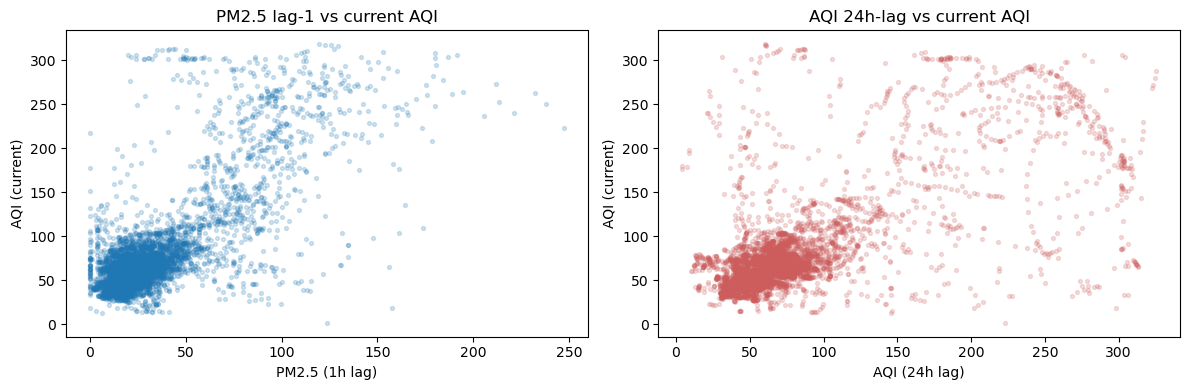

In [6]:
# Plot feature target relationships

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_model['pm25_lag1'], df_model['AQI'], alpha=0.2, s=8)
axes[0].set_xlabel('PM2.5 (1h lag)')
axes[0].set_ylabel('AQI (current)')
axes[0].set_title('PM2.5 lag-1 vs current AQI')

axes[1].scatter(df_model['AQI_lag24'], df_model['AQI'], alpha=0.2, s=8, color='indianred')
axes[1].set_xlabel('AQI (24h lag)')
axes[1].set_ylabel('AQI (current)')
axes[1].set_title('AQI 24h-lag vs current AQI')
plt.tight_layout()
plt.show()

In [7]:
# Save the output file

df_model.to_csv(OUT_PATH, index=False)
print(f"Saved {len(df_model)} rows, {len(feature_cols)} features to {OUT_PATH}")

Saved 6190 rows, 42 features to ../../datasets/processed/features.csv
